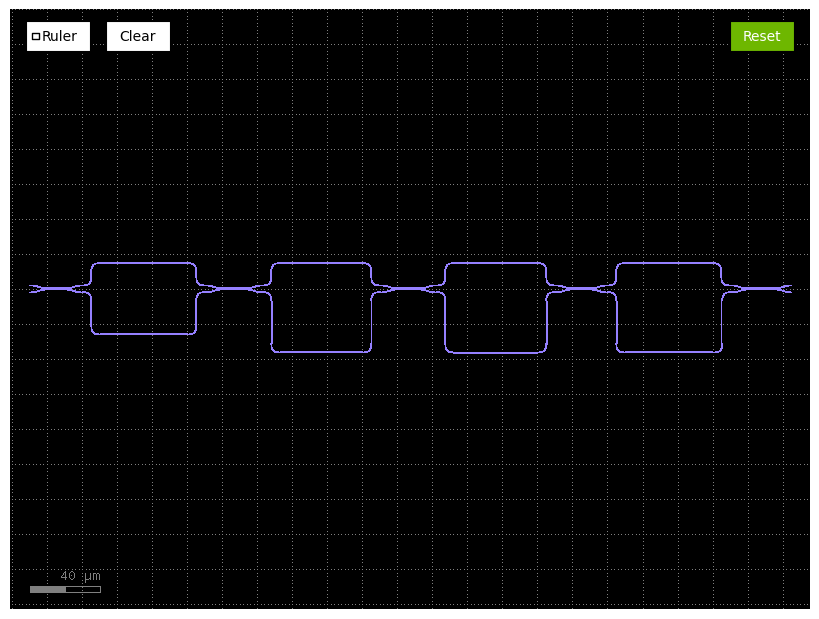

✅ GDS written to 'cband_mzi_2x2_grid.gds'


In [1]:
import gdsfactory as gf
import numpy as np
import cspdk.si220.cband
from axiomatic.pic_helpers import plot_circuit

# Activate the PDK
cspdk.si220.cband.activate_pdk()
pdk = gf.get_active_pdk()

def mzi_lattice_filter(
    delta_lengths: list[float],
    coupling_lengths: list[float],
    center_wvl: float = 1.55,
    coupling_gap: float = 0.2,
    n_g: float = 4.3,
    bend_radius: float = 5.0
) -> gf.Component:
    assert len(coupling_lengths) == len(delta_lengths) + 1, \
        "Need one more coupler than delay sections"

    c = gf.Component()
    coupler = lambda L: pdk.get_component("coupler", length=L, gap=coupling_gap)
    straight = lambda L: pdk.get_component("straight", length=L)

    stage_spacing = 100
    couplers = []

    # Place couplers
    for i, L in enumerate(coupling_lengths):
        dc = c << coupler(L)
        dc.move((i * stage_spacing, 0))
        couplers.append(dc)

    # Add 2×2 ports
    c.add_port("in0", port=couplers[0].ports["o2"])
    c.add_port("in1", port=couplers[0].ports["o1"])
    c.add_port("out0", port=couplers[-1].ports["o3"])
    c.add_port("out1", port=couplers[-1].ports["o4"])

    # Create delay arms
    for i, delta_L in enumerate(delta_lengths):
        top_src = couplers[i].ports["o3"]
        bot_src = couplers[i].ports["o4"]
        top_dst = couplers[i + 1].ports["o2"]
        bot_dst = couplers[i + 1].ports["o1"]
        detour_y = 15  # doesnt let me go from a bend to another bend directly

        # Geometry coordinates up
        x0, y0 = top_src.center
        x1, y1 = top_dst.center
        mid_x = (x0 + x1) / 2

        steps_top = [
            {"x": x0 + bend_radius},
            {"y": detour_y},
            {"x": x1 - bend_radius},
            {"y": y1},
        ]

        top_route = gf.routing.route_single(
            component=c,
            port1=top_src,
            port2=top_dst,
            steps=steps_top,
            bend="bend_euler",
            cross_section="strip"
        )

        x0, y0 = bot_src.center
        x1, y1 = bot_dst.center

        steps_bot = [
            {"x": x0 + bend_radius},
            {"y": -detour_y - delta_L/2},
            {"x": x1 - bend_radius},
            {"y": y1},
        ]
        # Bottom arm
        bot_route = gf.routing.route_single(
            component=c,
            port1=bot_src,
            port2=bot_dst,
            steps=steps_bot,
            bend="bend_euler",
            cross_section="strip"
        )

    return c

if __name__ == "__main__":
    lambda_c = 1.301  # µm
    n_eff = 2.38

    delta_L = 21.0  # µm
    delta_L_pi = lambda_c / (2 * n_eff)  # ≈ 0.273 µm
    delta_lengths = [
        delta_L,
        2 * delta_L,
        2 * delta_L + delta_L_pi,
        2 * delta_L
    ]

    coupling_lengths = [10, 13, 12, 10, 15]  # µm

    c = mzi_lattice_filter(
        delta_lengths=delta_lengths,
        coupling_lengths=coupling_lengths,
        center_wvl=lambda_c,
    )

    plot_circuit(c)

    # Save to GDS
    c.write_gds("cband_mzi_2x2_grid.gds", with_metadata=True)
    print("✅ GDS written to 'cband_mzi_2x2_grid.gds'")

